# FEM Pendulum
## Torque Application

The following section describes a method for applying a torque to a finite lement model (FEM) of a pendulum.
The pendulum is modeled in 2D plane strain conditions, with a fixed pivot at the top and free boundaries elsewhere.

The torque is applied on the rotation edge of the pendulum to induce rotational motion.
The challenge is to apply a pure torque without introducing additional net forces.

The torque is genrated by a distributed normal traction on the rotation boundary.
The traction distribution is designed to ensure that the net force is zero while producing the desired torque.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import scipy as scp

# Position of the hinge
cx = cy = 0

# X coordinate of the rotation edge in the reference configuration
rot_edge_x = np.linspace(-0.1, 0.1, 200)

# Normal on the rotation edge in the reference configuration
ref_normal = np.array([0, 1])

# Torque moment arm
torque_arm = -(rot_edge_x * ref_normal[1])

**Linear Traction Distribution:**
A linear traction distribution is used, where the traction varies linearly along the rotation edge.

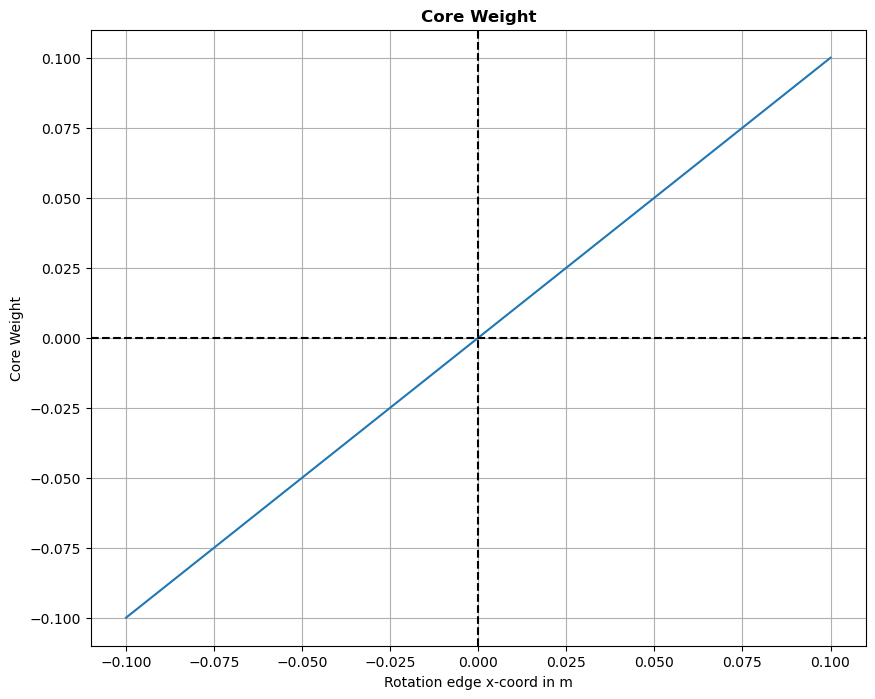

In [131]:
weight = 1 * rot_edge_x
plt.figure(figsize=(10, 8))
plt.title("Core Weight", fontweight="bold")
plt.plot(rot_edge_x, weight)
plt.axvline(0, color="k", linestyle="--")
plt.axhline(0, color="k", linestyle="--")
plt.grid(which="both")
plt.ylabel("Core Weight")
plt.xlabel("Rotation edge x-coord in m")
plt.show()

Effective Moment Arm: -0.000667 m
Drive parameter: -74996.2124081509


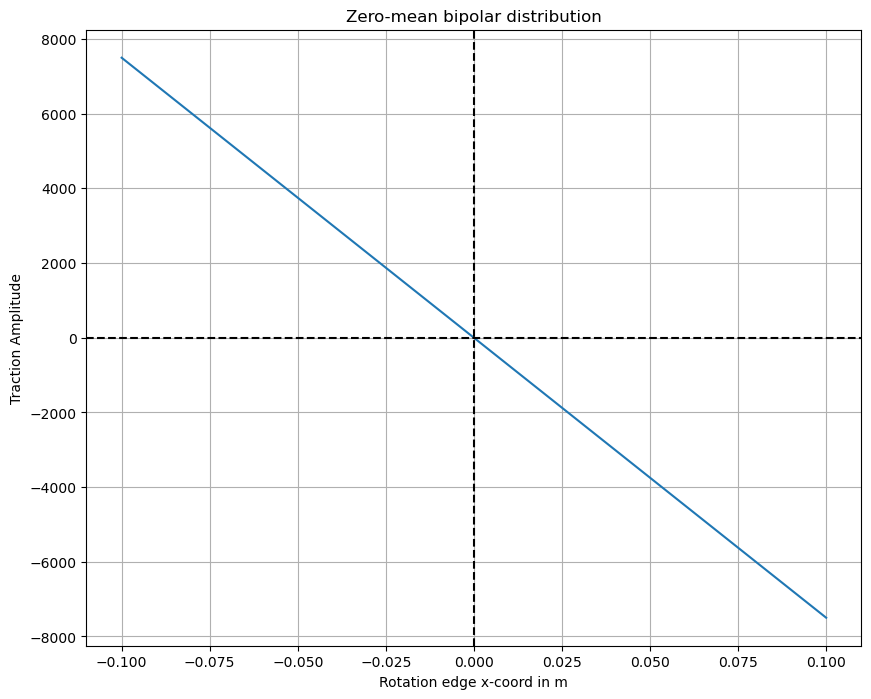

In [132]:
desired_torque = 50  # Nm
effective_moment_arm = scp.integrate.trapezoid(weight * torque_arm, rot_edge_x)
drive_parameter = desired_torque / effective_moment_arm

print(f"Effective Moment Arm: {effective_moment_arm:6f} m")
print(f"Drive parameter: {drive_parameter}")

traction_amplitude = drive_parameter * weight

plt.figure(figsize=(10, 8))
plt.title("Zero-mean bipolar distribution")
plt.plot(rot_edge_x, traction_amplitude)
plt.axvline(0, color="k", linestyle="--")
plt.axhline(0, color="k", linestyle="--")
plt.xlabel("Rotation edge x-coord in m")
plt.ylabel("Traction Amplitude")
plt.grid(which="both")
plt.show()

In [133]:
# verification
effective_traction = traction_amplitude * torque_arm
applied_torque = scp.integrate.trapezoid(effective_traction, rot_edge_x, 0.0001)

force_x = scp.integrate.trapezoid(traction_amplitude, rot_edge_x, 0.0001)

error = abs(desired_torque - applied_torque)
print(f"Desired Torque:    {desired_torque:.10f} Nm")
print(f"Applied Torque:    {applied_torque:.10f} Nm")
print(f"Torque abs. error: {error} Nm")

force_x

Desired Torque:    50.0000000000 Nm
Applied Torque:    50.0000000000 Nm
Torque abs. error: 0.0 Nm


np.float64(0.0)

------------------------------------

**Bipolar Traction Distribution:**

A bipolar traction distribution is used, where the traction is positive on one half of the rotation edge and negative on the other half.


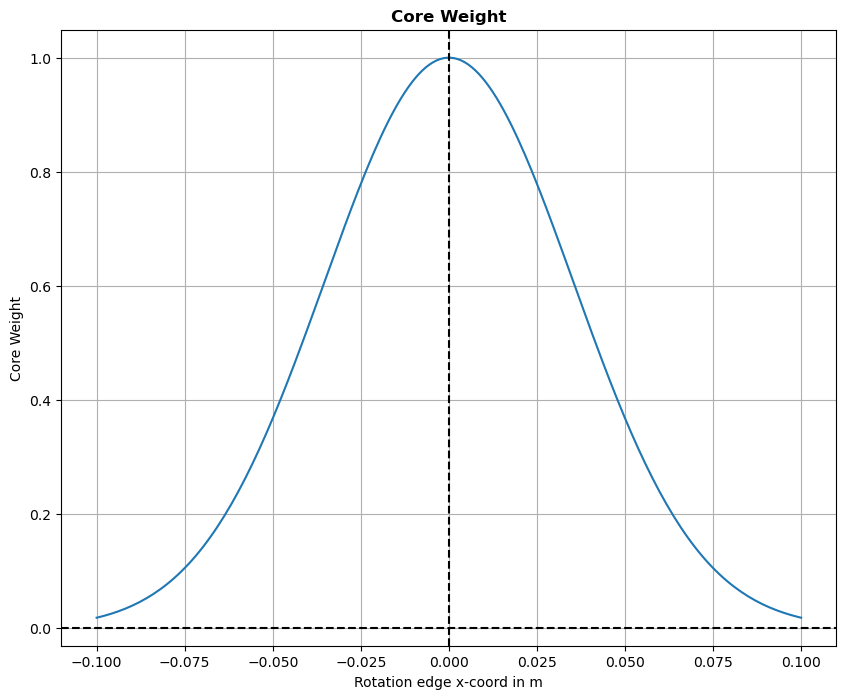

In [124]:
# Hinge radius
hinge_radius = 0.1
smoothening_width = 0.5 * hinge_radius
core_weight = np.exp(-(rot_edge_x * rot_edge_x) / (smoothening_width * smoothening_width))

plt.figure(figsize=(10, 8))
plt.title("Core Weight", fontweight="bold")
plt.plot(rot_edge_x, core_weight)
plt.axvline(0, color="k", linestyle="--")
plt.axhline(0, color="k", linestyle="--")
plt.grid(which="both")
plt.ylabel("Core Weight")
plt.xlabel("Rotation edge x-coord in m")
plt.show()

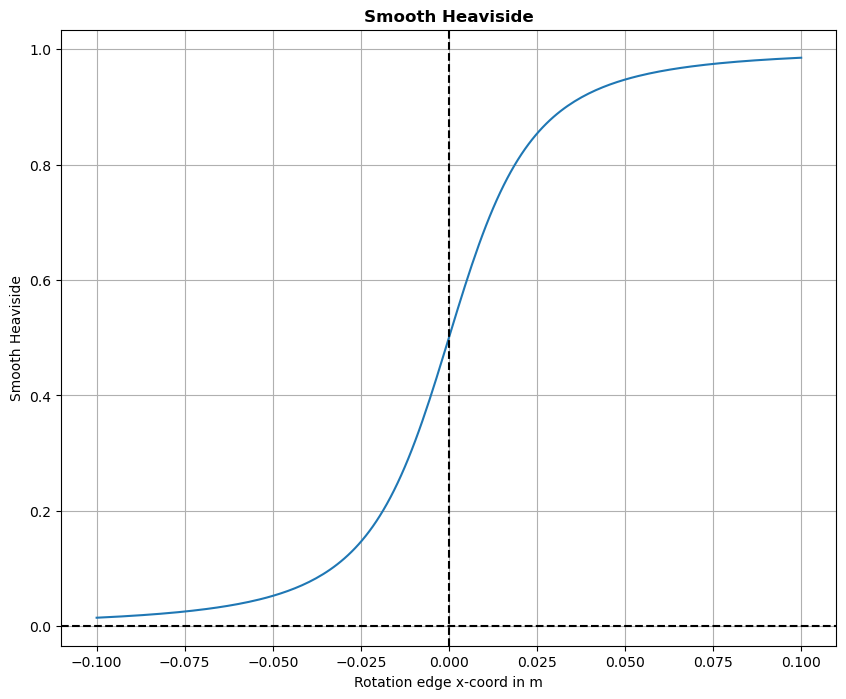

In [110]:
# Smooth heaviside function
heaviside_smoothing = 0.5 * smoothening_width
smooth_heaviside = 0.5 * (1 + rot_edge_x / np.sqrt(rot_edge_x**2 + heaviside_smoothing**2))

plt.figure(figsize=(10, 8))
plt.title("Smooth Heaviside", fontweight="bold")
plt.plot(rot_edge_x, smooth_heaviside)
plt.axvline(0, color="k", linestyle="--")
plt.axhline(0, color="k", linestyle="--")
plt.xlabel("Rotation edge x-coord in m")
plt.ylabel("Smooth Heaviside")
plt.grid(which="both")
plt.show()

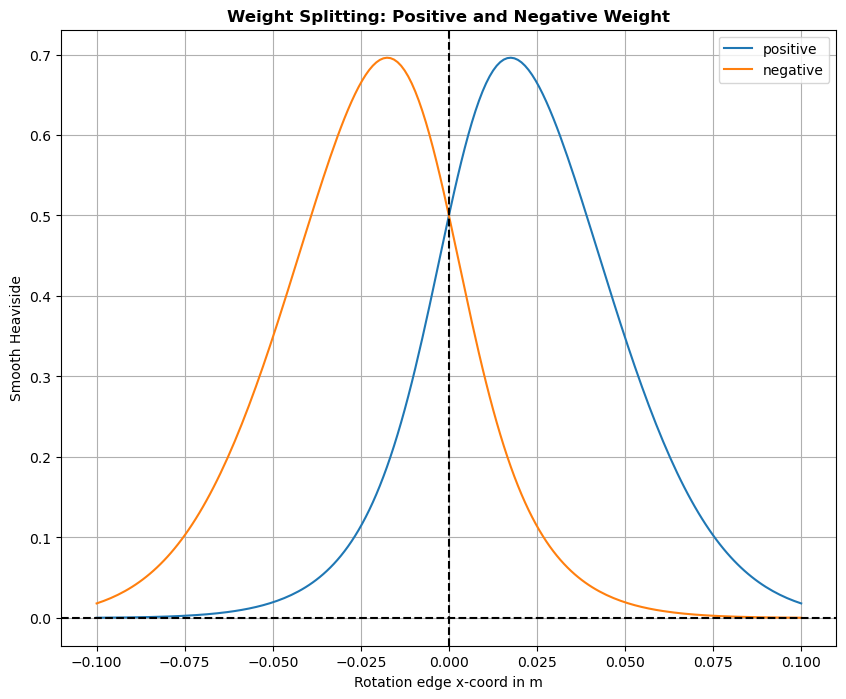

In [112]:
# Split into positive and negative regions
weight_positive = core_weight * smooth_heaviside
weight_negative = core_weight * (1.0 - smooth_heaviside)

plt.figure(figsize=(10, 8))
plt.title("Weight Splitting: Positive and Negative Weight", fontweight="bold")
plt.plot(rot_edge_x, weight_positive, label="positive")
plt.plot(rot_edge_x, weight_negative, label="negative")
plt.axvline(0, color="k", linestyle="--")
plt.axhline(0, color="k", linestyle="--")
plt.xlabel("Rotation edge x-coord in m")
plt.ylabel("Smooth Heaviside")
plt.grid(which="both")
plt.legend()
plt.show()

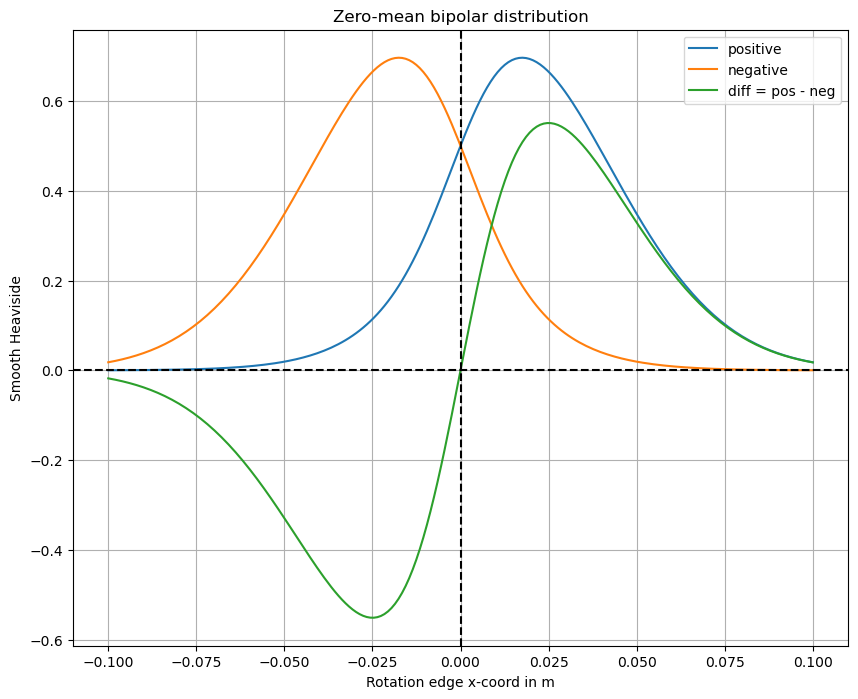

In [113]:
# Zero-mean bipolar distribution
weight_difference = weight_positive - weight_negative

plt.figure(figsize=(10, 8))
plt.title("Zero-mean bipolar distribution")
plt.plot(rot_edge_x, weight_positive, label="positive")
plt.plot(rot_edge_x, weight_negative, label="negative")
plt.plot(rot_edge_x, weight_difference, label="diff = pos - neg")
plt.axvline(0, color="k", linestyle="--")
plt.axhline(0, color="k", linestyle="--")
plt.xlabel("Rotation edge x-coord in m")
plt.ylabel("Smooth Heaviside")
plt.legend()
plt.grid(which="both")
plt.show()

Effective Moment Arm: -0.001947 m
Drive parameter: -25686.22160116444


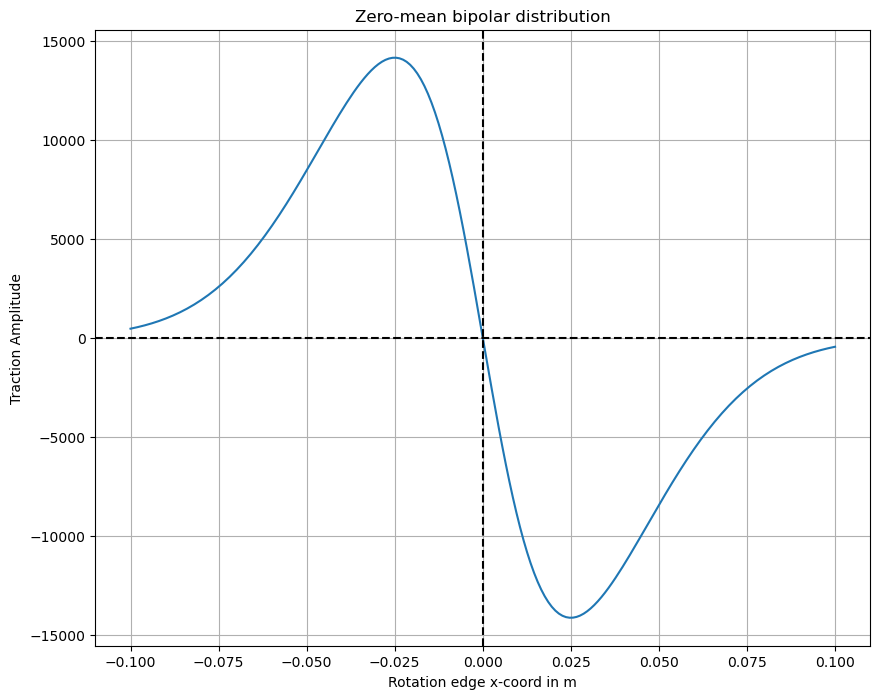

In [114]:
desired_torque = 50  # Nm
effective_moment_arm = scp.integrate.trapezoid(weight_difference * torque_arm, rot_edge_x)
drive_parameter = desired_torque / effective_moment_arm

print(f"Effective Moment Arm: {effective_moment_arm:6f} m")
print(f"Drive parameter: {drive_parameter}")

traction_amplitude = drive_parameter * weight_difference

plt.figure(figsize=(10, 8))
plt.title("Zero-mean bipolar distribution")
plt.plot(rot_edge_x, traction_amplitude)
plt.axvline(0, color="k", linestyle="--")
plt.axhline(0, color="k", linestyle="--")
plt.xlabel("Rotation edge x-coord in m")
plt.ylabel("Traction Amplitude")
plt.grid(which="both")
plt.show()

In [119]:
# verification
effective_traction = traction_amplitude * torque_arm
applied_torque = scp.integrate.trapezoid(effective_traction, rot_edge_x, 0.0001)

force_x = scp.integrate.trapezoid(traction_amplitude, rot_edge_x, 0.0001)

error = abs(desired_torque - applied_torque)
print(f"Desired Torque:    {desired_torque:.10f} Nm")
print(f"Applied Torque:    {applied_torque:.10f} Nm")
print(f"Torque abs. error: {error} Nm")

force_x

Desired Torque:    50.0000000000 Nm
Applied Torque:    50.0000000000 Nm
Torque abs. error: 1.4210854715202004e-14 Nm


np.float64(1.1368683772161603e-13)